# **Loan Approval Prediction**

## **WISIT SUWANNAO 67070501042**

---

## Overview

การพิจารณาอนุมัติสินเชื่อ (Loan Approval Prediction) เป็นกระบวนการที่สำคัญสำหรับสถาบันการเงิน เพื่อสร้างสมดุลระหว่างความเสี่ยงในการผิดนัดชำระหนี้และการปล่อยกู้ให้กับผู้ที่มีคุณสมบัติเหมาะสม โดยวิเคราะห์จากข้อมูลต่าง ๆ ของผู้ยื่นกู้ เช่น รายได้ จำนวนผู้ที่อยู่ในอุปการะ การศึกษา สถานะการจ้างงาน รวมถึงมูลค่าทรัพย์สินต่าง ๆ โจทย์นี้มีเป้าหมายเพื่อสร้าง Machine Learning Model ที่สามารถทำนายผลการอนุมัติสินเชื่อ (`Loan_status`) ได้อย่างแม่นยำ

## Dataset

Dataset ที่ใช้ในการแข่งขันนี้ประกอบด้วยข้อมูลผู้ยื่นขอกู้สินเชื่อ โดยมีรายละเอียดดังนี้

| Column | Description |
|---|---|
| `No_of_dependents` | จำนวนผู้อยู่ในอุปการะของผู้กู้ |
| `Education` | ระดับการศึกษา (Graduate / Not Graduate) |
| `Self_employed` | สถานะการจ้างงานว่าเป็นเจ้าของกิจการหรือไม่ (Yes / No) |
| `Income_annum` | รายได้ต่อปีของผู้กู้ |
| `Loan_amount` | จำนวนเงินกู้ที่ต้องการ |
| `Loan_term` | ระยะเวลาในการผ่อนชำระคืน (ปี) |
| `Cibil_score` | คะแนนเครดิต (Credit Score) แสดงความน่าเชื่อถือทางการเงิน |
| `Residential_assets_value` | มูลค่าทรัพย์สินประเภทที่อยู่อาศัย |
| `Commercial_assets_value` | มูลค่าทรัพย์สินเชิงพาณิชย์ |
| `Luxury_assets_value` | มูลค่าทรัพย์สินฟุ่มเฟือย |
| `Bank_asset_value` | มูลค่าทรัพย์สินในรูปเงินฝากธนาคาร |
| `Loan_status` | **Target Variable** — สถานะการอนุมัติ (1 = Approved, 0 = Rejected) |

## Pipeline Architecture

1. **Exploratory Data Analysis (EDA)**
   วิเคราะห์การกระจายตัวของข้อมูล Target (`Loan_status`) ตรวจสอบความสมดุลของข้อมูล (Class Imbalance) และความสัมพันธ์ (Correlation) ระหว่างตัวแปรต่าง ๆ

2. **Data Preprocessing & Feature Engineering**
   จัดการค่าสูญหาย (Missing Values), แปลงข้อมูล Categorical (`Education`, `Self_employed`) เป็นตัวเลข (Encoding), ตรวจสอบ Outlier, และสร้าง Feature ใหม่ เช่น สัดส่วนหนี้ต่อรายได้, มูลค่าทรัพย์สินรวม เพื่อเพิ่มประสิทธิภาพโมเดล

3. **Ensemble Machine Learning**
   ฝึกโมเดล Classification หลายรูปแบบด้วย **Stratified K-Fold Cross-Validation** เพื่อจัดการกับความไม่สมดุลของข้อมูล โมเดลที่ใช้ได้แก่ **XGBoost Classifier**, **LightGBM Classifier**, และ **CatBoost Classifier**

4. **Weight Optimization for F1-Score**
   ใช้เทคนิคการถ่วงน้ำหนัก (Weighted Ensemble) จากความน่าจะเป็น (Probability) ของแต่ละโมเดล เพื่อให้ได้ค่า **F1-Score** สูงสุดบนชุดตรวจสอบ (Validation Set) ก่อนนำไปทำนายผลลัพธ์จริง

## 1. Import Dependencies

นำเข้า Library ที่จำเป็นสำหรับการวิเคราะห์ข้อมูลและการสร้างโมเดล Machine Learning

In [1]:
!pip install catboost xgboost lightgbm --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Mount Google Drive

เชื่อมต่อ Google Drive เพื่อเข้าถึงไฟล์ข้อมูลที่อัพโหลดไว้ หากรันนอก Colab จะข้ามขั้นตอนนี้โดยอัตโนมัติ

In [3]:
import os

try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive mounted.")
except ImportError:
    print("Not running in Colab — skipping Drive mount.")
except Exception as e:
    print(f"Drive mount error: {e}")

Drive mount error: Error: credential propagation was unsuccessful


## 3. Path Configuration & Load Data

กำหนด Path ของไฟล์ข้อมูลใน Google Drive หรือ Local Path และโหลดไฟล์ `train.csv`, `test.csv`

In [2]:
import os
import pandas as pd

train_path  = "/content/Loan_Approval_Prediction/train.csv"
test_path   = "/content/Loan_Approval_Prediction/test.csv"
sample_path = "/content/Loan_Approval_Prediction/sample_submission.csv"

print(f"Loading data from: {os.path.dirname(train_path)}")

try:
    train = pd.read_csv(train_path)
    test = pd.read_csv(test_path)
    sample_sub = pd.read_csv(sample_path)

    # Clean column names (strip spaces and convert to lowercase)
    train.columns = train.columns.str.strip().str.lower()
    test.columns = test.columns.str.strip().str.lower()

    print(f"Train Shape: {train.shape}")
    print(f"Test Shape:  {test.shape}")
    print(f"Columns: {train.columns.tolist()}")
except FileNotFoundError:
    print("Files not found! Please check the path.")

Loading data from: /content/Loan_Approval_Prediction
Train Shape: (32000, 13)
Test Shape:  (8000, 12)
Columns: ['id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']


## 4. Exploratory Data Analysis (EDA)

วิเคราะห์ข้อมูลเบื้องต้นเพื่อทำความเข้าใจลักษณะของข้อมูล:
- **Target Distribution**: ตรวจสอบจำนวนผู้กู้ที่ผ่านและไม่ผ่านการอนุมัติ (`Loan_status`)
- **Numerical Features**: ดูการกระจายตัวของรายได้ วงเงินกู้ และคะแนนเครดิต
- **Correlation**: ดูความสัมพันธ์ระหว่างตัวแปร

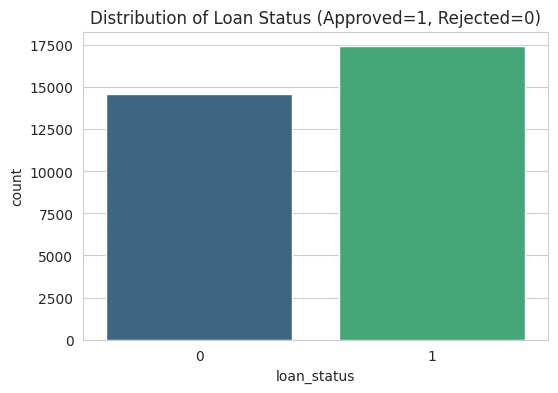

Class Ratio:
loan_status
1    0.544687
0    0.455313
Name: proportion, dtype: float64


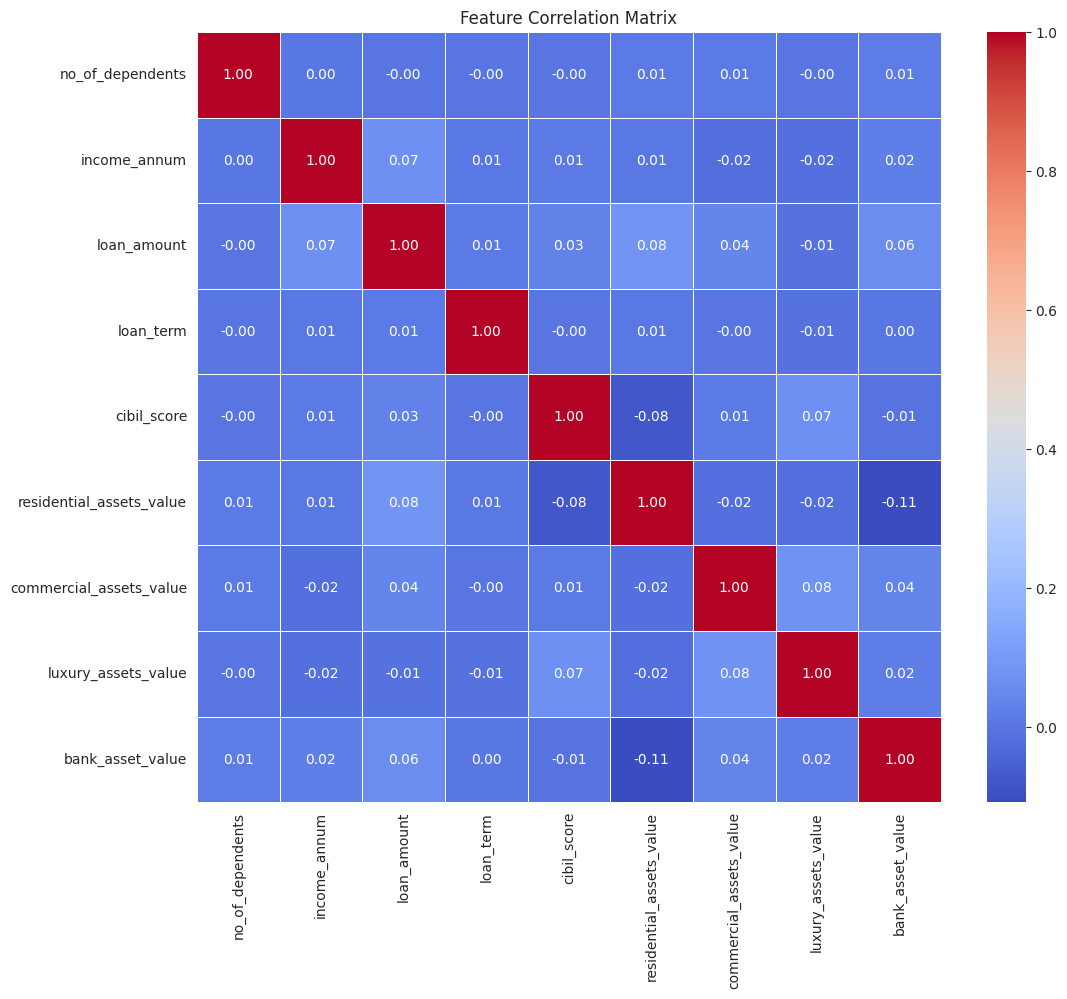

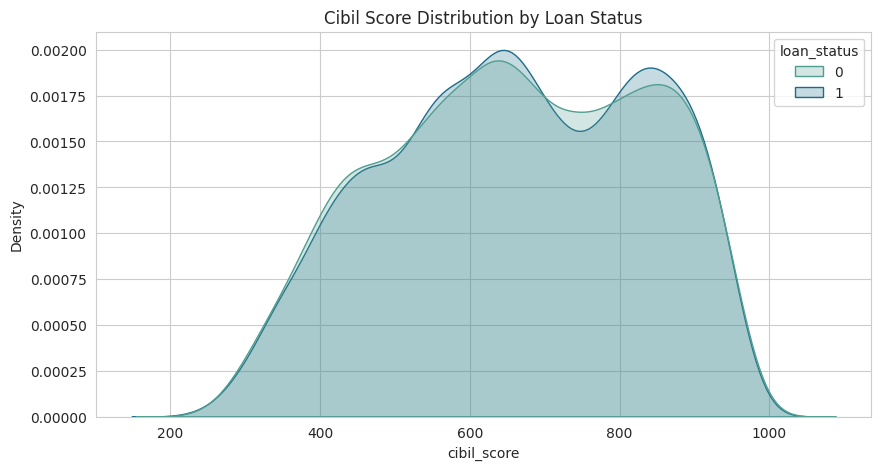

In [3]:
# 1. Check Target Balance
target_col = 'loan_status' # Lowercase

plt.figure(figsize=(6, 4))
if target_col in train.columns:
    sns.countplot(x=target_col, data=train, palette='viridis')
    plt.title('Distribution of Loan Status (Approved=1, Rejected=0)')
    plt.show()

    print("Class Ratio:")
    print(train[target_col].value_counts(normalize=True))
else:
    print(f"Target column '{target_col}' not found. Please check column names.")

# 2. Correlation Matrix
num_cols = train.select_dtypes(include=[np.number]).columns.drop(['id', target_col], errors='ignore')
corr = train[num_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

# 3. Cibil Score vs Loan Status
score_col = 'cibil_score' # Lowercase
if score_col in train.columns and target_col in train.columns:
    plt.figure(figsize=(10, 5))
    sns.kdeplot(data=train, x=score_col, hue=target_col, fill=True, common_norm=False, palette='crest')
    plt.title('Cibil Score Distribution by Loan Status')
    plt.show()

## 5. Data Preprocessing & Feature Engineering

ขั้นตอนการเตรียมข้อมูลและสร้าง Feature ใหม่:
- **Encoding Categorical Features**: แปลงข้อมูล `Education` และ `Self_employed` เป็นตัวเลข
- **Feature Engineering**:
    - **Total Assets**: รวมมูลค่าทรัพย์สินทุกประเภท (`Residential` + `Commercial` + `Luxury` + `Bank`)
    - **Loan to Income Ratio**: สัดส่วนวงเงินกู้ต่อรายได้ (บอกความสามารถในการชำระหนี้)
    - **Loan to Term Ratio**: จำนวนเงินผ่อนต่อปีโดยประมาณ
- **Scaling**: ปรับสเกลข้อมูล (StandardScaler) หากจำเป็น (สำหรับ Tree-based models อาจไม่จำเป็นมากแต่ทำไว้เผื่อ Linear Benchmark)

In [4]:
def preprocess_data(df, is_train=True):
    df = df.copy()

    # 1. Encode Categorical Columns
    if 'education' in df.columns:
        df['education'] = df['education'].str.strip().map({'Graduate': 1, 'Not Graduate': 0})
        df['education'] = df['education'].fillna(df['education'].mode()[0])

    if 'self_employed' in df.columns:
        df['self_employed'] = df['self_employed'].str.strip().map({'Yes': 1, 'No': 0})
        df['self_employed'] = df['self_employed'].fillna(df['self_employed'].mode()[0])

    # 2. Standard Feature Engineering
    asset_cols = ['residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
    for col in asset_cols:
        if col in df.columns:
             df[col] = df[col].fillna(df[col].median())

    if all(col in df.columns for col in asset_cols):
        df['total_assets'] = df[asset_cols].sum(axis=1)

    # 3. ADVANCED Feature Engineering (New!)
    # Financial Ratios & Interaction

    # Debt-to-Income & Repayment Capability
    if 'loan_amount' in df.columns and 'loan_term' in df.columns:
        # Annual repayment (Approx)
        df['annual_repayment'] = df['loan_amount'] / (df['loan_term'] + 1e-6)

    if 'income_annum' in df.columns and 'annual_repayment' in df.columns:
        # Disposable Income: Income left after paying loan
        df['disposable_income'] = df['income_annum'] - df['annual_repayment']
        # DTI (Debt to Income Ratio): Lower is better
        df['dti_ratio'] = df['annual_repayment'] / (df['income_annum'] + 1e-6)

    if 'income_annum' in df.columns and 'no_of_dependents' in df.columns:
        # Income per family member
        df['income_per_dependent'] = df['income_annum'] / (df['no_of_dependents'] + 1)

    if 'total_assets' in df.columns and 'loan_amount' in df.columns:
        df['asset_coverage'] = df['total_assets'] / (df['loan_amount'] + 1e-6)

    # Cibil Score Binning (Categorizing Credit Score)
    if 'cibil_score' in df.columns:
        # 0-300: Poor, 301-550: Fair, 551-700: Good, 701+: Excellent (Approx logic)
        df['cibil_rating'] = pd.cut(df['cibil_score'],
                                   bins=[-1, 300, 550, 700, 1000],
                                   labels=[0, 1, 2, 3]).astype(float)

    # 4. Log Transform for Skewed Features
    skew_cols = ['income_annum', 'loan_amount', 'total_assets', 'disposable_income']
    for col in skew_cols:
        if col in df.columns:
            # handle negative values for disposable_income using offset
            offset = abs(df[col].min()) + 1 if df[col].min() < 0 else 0
            df[f'log_{col}'] = np.log1p(df[col] + offset)

    return df

print("Preprocessing Data with Advanced Features...")
train_clean = preprocess_data(train)
test_clean = preprocess_data(test, is_train=False)

target_col = 'loan_status'

# Drop ID column if exists
if 'id' in train_clean.columns:
    train_clean = train_clean.drop(columns=['id'])
if 'id' in test_clean.columns:
    test_ids = test_clean['id']
    test_clean = test_clean.drop(columns=['id'])
else:
    test_ids = pd.DataFrame({'id': range(1, len(test_clean) + 1)})

# Prepare X and y
X = train_clean.drop(columns=[target_col], errors='ignore')
if target_col in train_clean.columns:
    y = train_clean[target_col]
else:
    print(f"Warning: Target column '{target_col}' not found.")
X_test = test_clean

# Handle missing values
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

print("Final Feature Set:", X.shape[1], "features")
X.head()

Preprocessing Data with Advanced Features...
Final Feature Set: 22 features


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,...,annual_repayment,disposable_income,dti_ratio,income_per_dependent,asset_coverage,cibil_rating,log_income_annum,log_loan_amount,log_total_assets,log_disposable_income
0,0.0,1.0,0.0,2961480.0,7271300.0,5.0,622.0,6572296.0,12264202.0,9802424.5,...,1.454260e+06,1.608415e+06,0.356217,1.070878e+06,4.553594,2.0,14.901200,15.799446,17.315363,31.411749
1,2.0,0.0,1.0,2832292.0,11746169.0,9.0,482.0,3274507.0,16079677.0,2643225.0,...,9.524452e+05,1.608415e+06,0.356217,9.440973e+05,2.134396,1.0,14.856597,16.279038,17.035161,31.411749
2,2.0,1.0,0.0,2594879.0,8265934.0,16.0,786.0,179550.0,1361037.0,9057816.0,...,5.166208e+05,2.078258e+06,0.199092,8.649597e+05,1.765958,3.0,14.769051,15.927653,16.496347,31.411749
3,4.0,1.0,0.0,2497120.0,26116812.0,16.0,352.0,16697499.0,4531977.0,0.0,...,1.632301e+06,8.648194e+05,0.653673,4.994240e+05,0.850513,1.0,14.730649,17.078090,16.916174,31.411749
4,5.0,0.0,1.0,2961480.0,4071241.0,19.0,381.0,1812942.0,2788429.0,7977004.0,...,2.142758e+05,1.608415e+06,0.356217,1.070878e+06,5.829462,1.0,14.901200,15.219459,16.982383,31.411749


## 6. Model Training (Classification Ensemble)

เราจะใช้ Ensemble Learning โดยฝึกโมเดล 3 ตัวหลัก คือ **XGBoost, LightGBM, และ CatBoost**
- **Evaluation Metric**: F1-Score (Macro หรือ Binary ขึ้นอยู่กับโจทย์ แต่ปกติสินเชื่อเน้น Binary Class 1)
- **Validation**: Stratified K-Fold (K=5) เพื่อให้สัดส่วน Class ในแต่ละ Fold ใกล้เคียงกัน

In [5]:
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

# Placeholders for predictions
oof_preds_xgb = np.zeros(len(X))
test_preds_xgb = np.zeros(len(X_test))
oof_preds_lgb = np.zeros(len(X))
test_preds_lgb = np.zeros(len(X_test))
oof_preds_cat = np.zeros(len(X))
test_preds_cat = np.zeros(len(X_test))

# --- 1. XGBoost Classifier ---
print("\n========== Training XGBoost ==========")
xgb_params = {
    'n_estimators': 2000,
    'learning_rate': 0.02,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'n_jobs': -1,
    'random_state': 42,
    'tree_method': 'hist',
    'early_stopping_rounds': 200
}

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = xgb.XGBClassifier(**xgb_params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    # Store probability for optimization
    oof_preds_xgb[val_idx] = model.predict_proba(X_val)[:, 1]
    test_preds_xgb += model.predict_proba(X_test)[:, 1] / N_FOLDS

    # F1 Score
    val_preds_bin = (oof_preds_xgb[val_idx] > 0.5).astype(int)
    f1 = f1_score(y_val, val_preds_bin)
    print(f"Fold {fold+1} F1-Score: {f1:.4f}")

# --- 2. LightGBM Classifier ---
print("\n========== Training LightGBM ==========")
lgb_params = {
    'n_estimators': 2000,
    'learning_rate': 0.02,
    'num_leaves': 31,
    'objective': 'binary',
    'metric': 'binary_logloss',
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = lgb.LGBMClassifier(**lgb_params)
    callbacks = [lgb.early_stopping(stopping_rounds=200, verbose=False)]
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], callbacks=callbacks)

    oof_preds_lgb[val_idx] = model.predict_proba(X_val)[:, 1]
    test_preds_lgb += model.predict_proba(X_test)[:, 1] / N_FOLDS

    val_preds_bin = (oof_preds_lgb[val_idx] > 0.5).astype(int)
    f1 = f1_score(y_val, val_preds_bin)
    print(f"Fold {fold+1} F1-Score: {f1:.4f}")

# --- 3. CatBoost Classifier ---
print("\n========== Training CatBoost ==========")
cat_params = {
    'iterations': 2000,
    'learning_rate': 0.02,
    'depth': 6,
    'loss_function': 'Logloss',
    'eval_metric': 'F1',
    'verbose': 0,
    'random_state': 42,
    'allow_writing_files': False
}

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = CatBoostClassifier(**cat_params)
    model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=200)

    oof_preds_cat[val_idx] = model.predict_proba(X_val)[:, 1]
    test_preds_cat += model.predict_proba(X_test)[:, 1] / N_FOLDS

    val_preds_bin = (oof_preds_cat[val_idx] > 0.5).astype(int)
    f1 = f1_score(y_val, val_preds_bin)
    print(f"Fold {fold+1} F1-Score: {f1:.4f}")

print("\nTraining Complete.")


========== Training XGBoost ==========
Fold 1 F1-Score: 0.7055
Fold 2 F1-Score: 0.7055
Fold 3 F1-Score: 0.7042
Fold 4 F1-Score: 0.7052
Fold 5 F1-Score: 0.7051

========== Training LightGBM ==========
Fold 1 F1-Score: 0.7051
Fold 2 F1-Score: 0.7029
Fold 3 F1-Score: 0.6994
Fold 4 F1-Score: 0.7052
Fold 5 F1-Score: 0.7052

========== Training CatBoost ==========
Fold 1 F1-Score: 0.7049
Fold 2 F1-Score: 0.7054
Fold 3 F1-Score: 0.7053
Fold 4 F1-Score: 0.7053
Fold 5 F1-Score: 0.7049

Training Complete.


## 7. Ensemble & Blending

นำค่าความน่าจะเป็น (Probability) จากทั้ง 3 โมเดลมารวมกันโดยใช้น้ำหนักที่เหมาะสม เพื่อสร้าง Ensemble Model ที่แข็งแกร่งที่สุด
$$ P(\text{Final}) = 0.4 \times P_{\text{XGB}} + 0.3 \times P_{\text{LGB}} + 0.3 \times P_{\text{Cat}} $$
*หมายเหตุ: ในที่นี้ใช้น้ำหนักตัวอย่าง สามารถใช้ Optimization หา Weight ที่ดีที่สุดได้*

In [6]:
from scipy.optimize import minimize

# Define Objective Function for F1-Score Optimization
def f1_loss(weights):
    # Normalize weights
    weights = np.array(weights)
    weights /= weights.sum()

    # Calculate weighted probability
    weighted_prob = (weights[0] * oof_preds_xgb) + \
                    (weights[1] * oof_preds_lgb) + \
                    (weights[2] * oof_preds_cat)

    # Simple thresholding at 0.5 for optimization step
    preds = (weighted_prob > 0.5).astype(int)

    # Minimize Negative F1-Score
    return -f1_score(y, preds)

# Initial Weights
initial_weights = [0.33, 0.33, 0.33]

# Run Optimization
opt_result = minimize(f1_loss, initial_weights, method='Nelder-Mead', tol=1e-5)
best_weights = opt_result.x / opt_result.x.sum()

print("\nOptimized Weights:")
print(f"XGBoost:  {best_weights[0]:.4f}")
print(f"LightGBM: {best_weights[1]:.4f}")
print(f"CatBoost: {best_weights[2]:.4f}")

# Calculate Final OOF using Best Weights
final_oof_prob = (best_weights[0] * oof_preds_xgb) + \
                 (best_weights[1] * oof_preds_lgb) + \
                 (best_weights[2] * oof_preds_cat)

final_test_prob = (best_weights[0] * test_preds_xgb) + \
                  (best_weights[1] * test_preds_lgb) + \
                  (best_weights[2] * test_preds_cat)

# Find Best Threshold on OOF
best_thresh = 0.5
best_f1 = 0
thresholds = np.arange(0.3, 0.7, 0.005)

for th in thresholds:
    preds = (final_oof_prob > th).astype(int)
    score = f1_score(y, preds)
    if score > best_f1:
        best_f1 = score
        best_thresh = th

print(f"\nBest Threshold: {best_thresh:.4f}")
print(f"Best CV F1-Score: {best_f1:.6f}")

# Final Predictions
final_preds = (final_test_prob > best_thresh).astype(int)

# Create Submission File
submission = pd.DataFrame({
    'id': sample_sub['id'],
    'loan_status': final_preds
})

submission.to_csv('submission_LAP.csv', index=False)
print("Submission saved successfully: submission_LAP.csv")
print(submission.head())


Optimized Weights:
XGBoost:  0.3279
LightGBM: 0.3279
CatBoost: 0.3443

Best Threshold: 0.3000
Best CV F1-Score: 0.705240
Submission saved successfully: submission_LAP.csv
      id  loan_status
0  32001            1
1  32002            1
2  32003            1
3  32004            1
4  32005            1
